 # Email Phishing Detection Model with BERT for Tokenization

For more information regarding the model and other important information, check the README file.

**AVN Phishing Email Classification Dataset**\
From AVN Bluefox (Amritha V Nair) - 2025. Under CC BY 4.0 License\
https://www.kaggle.com/datasets/avnbluefox/avn-phishing-email-classification-dataset?select=AVN_Corpus.csv

## Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from email.utils import parseaddr

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import keras
import keras_hub
import tensorflow as tf

2026-07-31 12:58:59.943789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-31 12:58:59.996805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-31 12:59:01.074461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/prism/dev/repos/phishing-detection-with-bert-tokenizer/.venv/lib/python3.12/site-pack

In [2]:
df = pd.read_csv('data/AVN_Corpus.csv')
df

,subject,receiver,sender,label,body,urls,date
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,"Tue, 05 Aug 2008 16:31:02 -0700"
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,"Tue, 05 Aug 2008 18:31:03 -0500"
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,"Tue, 05 Aug 2008 20:28:00 -1200"
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,"Tue, 05 Aug 2008 17:31:20 -0600"
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,"Tue, 05 Aug 2008 19:31:21 -0400"
...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,NaN,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,NaN
59432,TREAT AS URGENT.,NaN,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,"Mon, 17 Sep 2007 22:28:11 +0000"
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,NaN,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,"Tue, 18 Sep 2007 10:54:53 +0000"
59434,My Beloved In Christ.,NaN,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,"Wed, 19 Sep 2007 00:52:16 +0100"


We first check to see the distribution of null values to see how we should perform data cleaning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59436 entries, 0 to 59435
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   48209 non-null  str    
 1   receiver  46296 non-null  str    
 2   sender    47961 non-null  str    
 3   label     59436 non-null  float64
 4   body      59436 non-null  str    
 5   urls      59436 non-null  int64  
 6   date      47810 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 3.2 MB


We first perform checks on the `label` variable to identify any potential class imbalance within the dataset.

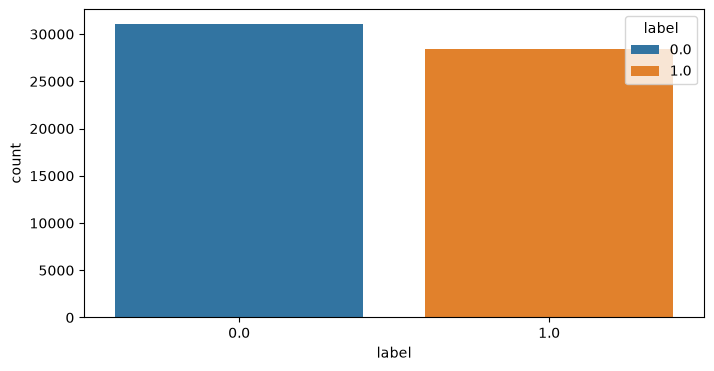

label
0.0    31053
1.0    28383
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='label', hue='label')
plt.show()

df['label'].value_counts()

From the `label` data above, the class distribution is roughly **even**, with a distribution of:
- 31,053 (52.2%) of emails being normal
- 28,383 (47.8%) of emails being malicious

The null values with `subject`, `sender`, `receiver` and `date` fields make up ~20% of the total number of fields within the dataset.

Hence, we fill the null values for `subject`, `sender` and `receiver` with **"Unknown"** fields as these null values can have potentially reveal special relationships within the data.

For the `date` field, an indicator `is_date_valid` to check whether it has a defined (and valid) date and then parse the value within `date` (see below).

In [5]:
df["subject"] = df["subject"].fillna("No Subject")
df["sender"] = df["sender"].fillna("Unknown Sender")
df["receiver"] = df["receiver"].fillna("Unknown Receiver")

df["is_date_invalid"] = df["date"].isna().astype(np.float32) # 1 if invalid, 0 if valid

df.sample(5)

,subject,receiver,sender,label,body,urls,date,is_date_invalid
40065,No Subject,Unknown Receiver,Unknown Sender,0.0,My love ! How come it took you so long to leav...,0,NaN,1.0
31571,Re:,user2.13@gvc.ceas-challenge.cc,Deontae Hoffman <unthinkinglygpv71@magicalmari...,1.0,"\nDon't find love, let love find you. That's w...",1,"Thu, 07 Aug 2008 21:01:06 -0300",0.0
58233,HELLO SIR,dr97@CU,cheung pu <cheugpuixx7@yahoo.com.hk>,1.0,FROM: MR CHEUNG PUI\n\ncheugpuixx7@yahoo.com.h...,0,"Fri, 26 May 2006 19:49:35 +0100",0.0
25896,CNN.com Daily Top 10,user2.6@gvc.ceas-challenge.cc,Daily Top 10 <lertep_1976@pasqualiparise.com.br>,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,"Thu, 07 Aug 2008 16:13:26 +0200",0.0
5899,Spring Big Sale...FANTASTIC Replica watches......,user2.13@gvc.ceas-challenge.cc,Cecelia Dewitt <OlivegrowthPelletier@coloring.ws>,1.0,\nThey look and feel exactly like the real thi...,1,"Tue, 05 Aug 2008 19:43:49 +0500",0.0


The `date` column **is adjusted for UTC**, and then parsed into 4 unique fields which are:
- `hour`
- `day_of_week`: day of the week (Mon (0) - Sun (6))
- `month`
- `year`

The original `date` column will be dropped.

In [6]:
df['date'] = pd.to_datetime(df['date'], errors="coerce", utc=True)

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df = df.drop('date', axis=1)

df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,month,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,8.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,8.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,8.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,8.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,8.0,2008.0
...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,9.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,9.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,9.0,2007.0


With the extracted subfields, we perform EDA to explore patterns with how these features interact with the target variable.

We first analyze the distribution of emails based on the time of day (`hour`), to answer whether:
- Are phishing emails more common within certain times of the day, such as working hours?
- Do most legitimate emails occur within the same time range as most phishing emails?

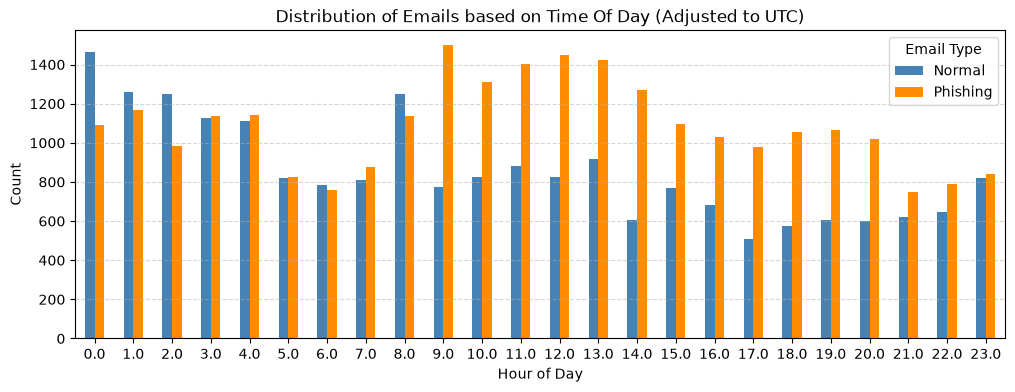

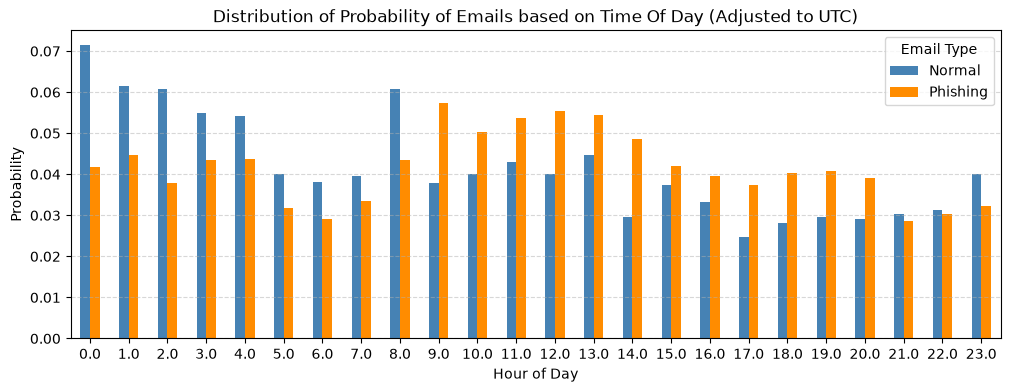

In [7]:
# pure count
counts = pd.crosstab(df['hour'], df['label'])
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['hour'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Probability of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Based on the distribution of data, we find that:
- Most phishing emails are present throughout **09:00 to 20:00 UTC**, with most legitimate ones being distributed mostly between **23:00 to 04:00** and **08:00 UTC**
- There is a **clear difference** between the distribution of normal and phishing emails

Hence, we keep the `hour` feature as we believe that this feature contains useful predictive power.

After parsing `hour`, we then analyze the day of the week (`day_of_week`) to answer:
- Are phishing emails more common within weekdays as supposed to weekends?
- What is the overall distribution of emails within the week?

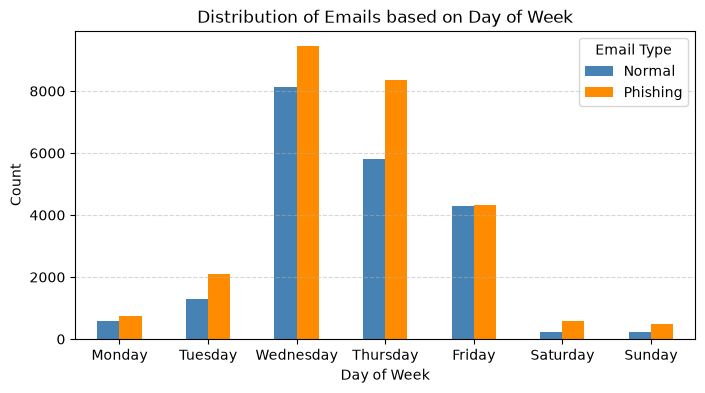

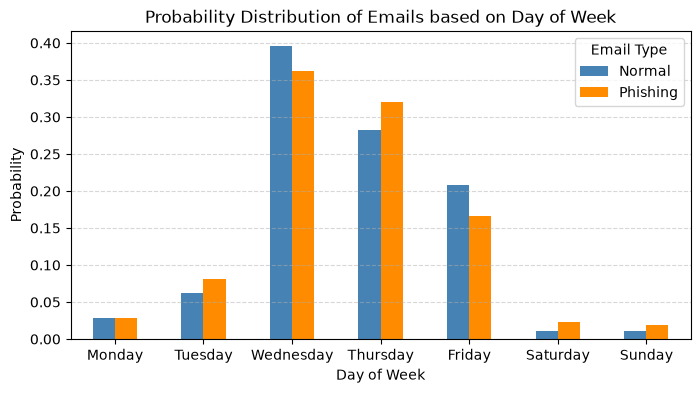

In [8]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# pure count
counts = pd.crosstab(df['day_of_week'], df['label'])
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['day_of_week'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Probability Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Majority** of all emails fall within **Wednesday to Friday**, with the **weekends tending to have significant lower emails**
- Normal emails and phishing emails follow the **same trend** throughout the week

Therefore, we keep the `day_of_week` feature as we believe that feature is useful in predicting the trends of emails throughout the week.

After parsing `month`, we then analyze the month of the year (`month`) to answer:
- Are there any trends in phishing emails based on the months of the year?
- What is the overall distribution of emails within the year, do summer / winter holiday periods reduce the number?

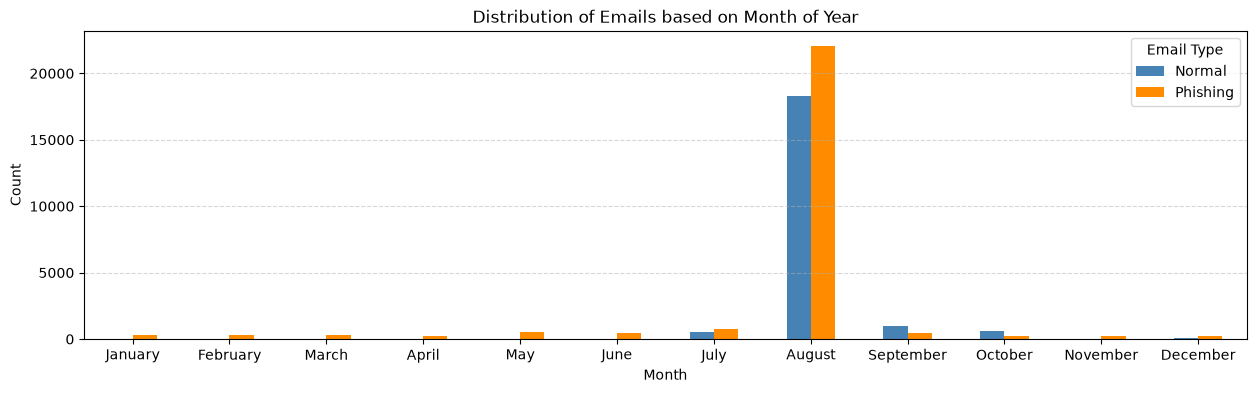

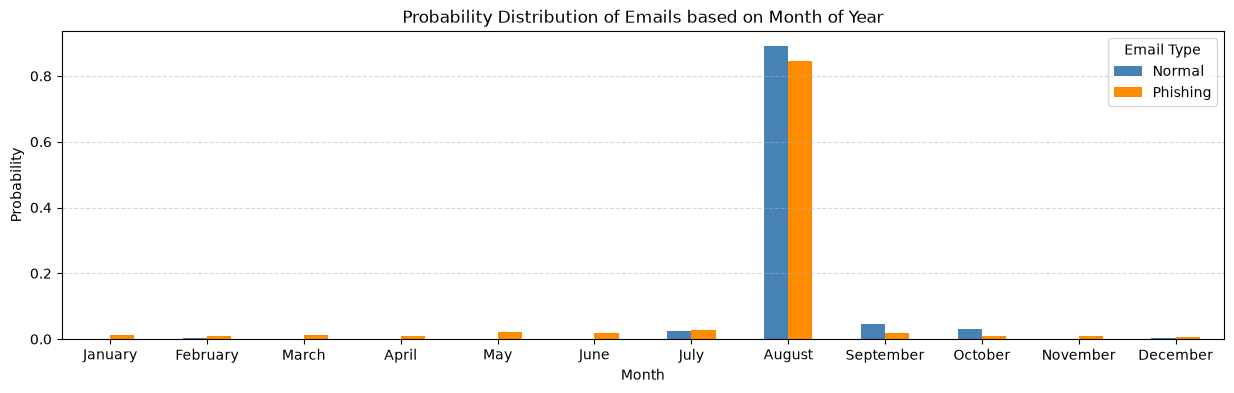

In [9]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# pure count
counts = pd.crosstab(df['month'], df['label'])
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['month'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Probability Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Practically all emails are sent from August**, other months have a *negligible* percentage of emails
- Both normal and phishing emails follow this trend

Thus, we decide to drop `month`, since we believe that this distribution is because of how the data within the dataset was obtained.

In [10]:
df = df.drop('month', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,2008.0
...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,2007.0


The `year` column, just like `month`, contains a heavily imbalanced set, with **2008 making up more than 65% of emails**.

Hence, we also drop `year` since it doesn't contain any useful predictive value.

In [11]:
df['year'].value_counts()

year
2008.0    38947
2002.0     4548
2006.0     1006
2005.0      553
2007.0      466
2004.0      424
2003.0      396
2001.0      109
102.0        59
2000.0       35
2009.0       15
1980.0       12
1998.0        7
1999.0        6
2100.0        4
2020.0        4
1986.0        2
1990.0        2
2086.0        1
2012.0        1
2080.0        1
2031.0        1
1981.0        1
2010.0        1
2028.0        1
1997.0        1
2082.0        1
2015.0        1
Name: count, dtype: int64

In [12]:
df = df.drop('year', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0
...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0


For `sender` and `receiver`, it would likely better to extract the features given that the domain of the email and other information is more useful.

We use the `parseaddr()` function provided by Python's `email` stdlib import, which handles most of the raw email parsing.
After parsing, we split the contents of the email into different components, like name, username, domain, TLD, before feature engineering.

From these components, we then obtain the following features:
- **Boolean variables**: 1 for yes, 0 for no
    - `is_sender_name_missing`
    - `is_sender_email_missing`
    - `sender_email_has_digits`
    - `sender_email_has_hyphens`
- **Countable variables**
    - `sender_username_length`
    - `receiver_username_length`
    - `sender_domain_length`
    - `receiver_domain_length`

In [13]:
def parse_sender_receiver(raw):
    name, email = parseaddr(raw)
    name = name.strip().replace('\\"', '"').strip('"').strip()
    email = email.lower().strip()
    return name, email

def extract_email_components(email):
    if '@' not in email:
        return "", ""
    username, domain = email.split('@', 1)
    return username, domain

df[["sender_displayname", "sender_email"]] = df['sender'].apply(parse_sender_receiver).apply(pd.Series)
df[["receiver_displayname", "receiver_email"]] = df["receiver"].apply(parse_sender_receiver).apply(pd.Series)

df[["sender_username", "sender_domain"]] = df["sender_email"].apply(extract_email_components).apply(pd.Series)
df[["receiver_username", "receiver_domain"]] = df["receiver_email"].apply(extract_email_components).apply(pd.Series)

df["is_sender_displayname_missing"] = (df["sender_displayname"] == "").astype(int)
df["is_sender_email_missing"] = (df["sender_email"].str.contains("@", na=False) == False).astype(int)

df["sender_email_digit_count"] = df["sender_email"].str.count(r"\d")
df["sender_email_has_hyphens"] = df["sender_email"].str.contains("-").astype(int)

df['sender_username_length'] = df['sender_username'].str.len()
df['receiver_username_length'] = df['receiver_username'].str.len()

df['sender_domain_length'] = df['sender_domain'].str.len()
df['receiver_domain_length'] = df['receiver_domain'].str.len()

# drop the sender and receiver column, as well as the other temporary features
df = df.drop(['sender', 'sender_displayname', 'sender_email', 'sender_username', 'sender_domain'], axis=1)
df = df.drop(['receiver', 'receiver_displayname', 'receiver_email', 'receiver_username', 'receiver_domain'], axis=1)

df

,subject,label,body,urls,is_date_invalid,hour,day_of_week,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,receiver_username_length,sender_domain_length,receiver_domain_length
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,0,0,0,0,5,5,9,21
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,0,0,4,0,12,7,9,21
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,0,0,0,1,19,7,19,21
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,0,0,0,0,7,3,9,23
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,0,0,1,0,12,7,19,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,1,0,4,0,14,0,14,0
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,0,0,3,0,13,0,10,0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,0,0,2,0,18,0,10,0
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,0,0,2,0,14,0,11,0


We first perform EDA on the boolean variables, by analyzing what is the proportion of phishing emails and normal emails correlate with these features.

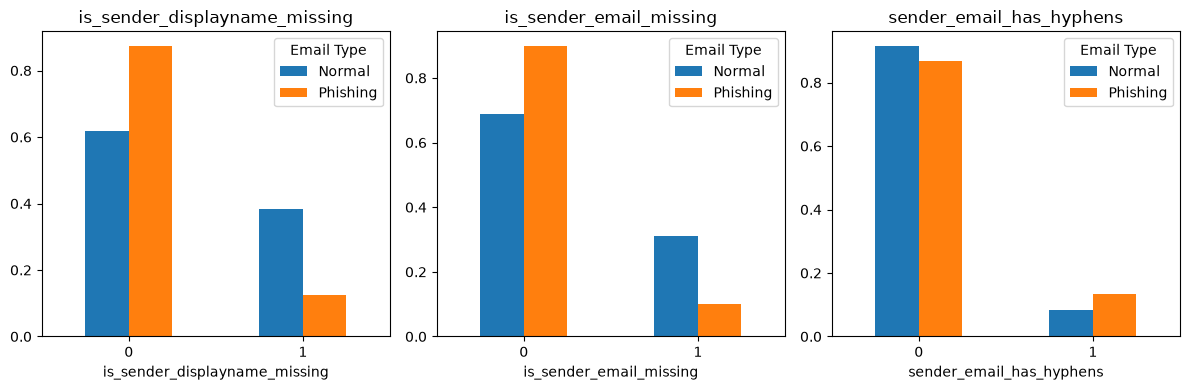

In [14]:
bool_features = [
    "is_sender_displayname_missing",
    "is_sender_email_missing",
    "sender_email_has_hyphens",
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, feature in zip(axes.flatten(), bool_features):
    pd.crosstab(
        df[feature],
        df["label"],
        normalize='columns'
    ).plot(kind='bar', ax=ax)
    ax.legend(title="Email Type", labels=["Normal", "Phishing"])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(feature)

plt.tight_layout()

Based on the results, we find that:
- Emails where the **sender has hyphens** are slightly more likely to be a phishing email than a normal email
- Normal emails are **more likely to have the sender email / display name missing** compared to a phishing email, contrary to assumptions

We then analyze the countable features, to look at the trend of how the distributions differ between legitimate and phishing emails

sender_username_length                      receiver_username_length  \
                      median       mean       std                   median   
label                                                                        
0.0                      5.0   5.821531  5.529793                      4.0   
1.0                     11.0  10.598386  6.063010                      7.0   

                          sender_email_digit_count                      \
           mean       std                   median      mean       std   
label                                                                    
0.0    5.032622  5.193890                      0.0  0.155991  0.981839   
1.0    7.172920  4.347549                      0.0  0.868513  1.853595   

      sender_domain_length                      receiver_domain_length  \
                    median       mean       std                 median   
label                                                                    
0.0                    9.0   8.510869  6.835133                   10.0   
1.0                   12.0  11.745939  5.692323                   21.0   

                            
            mean       std  
label                       
0.0     8.987892  8.254926  
1.0    16.677976  8.052945

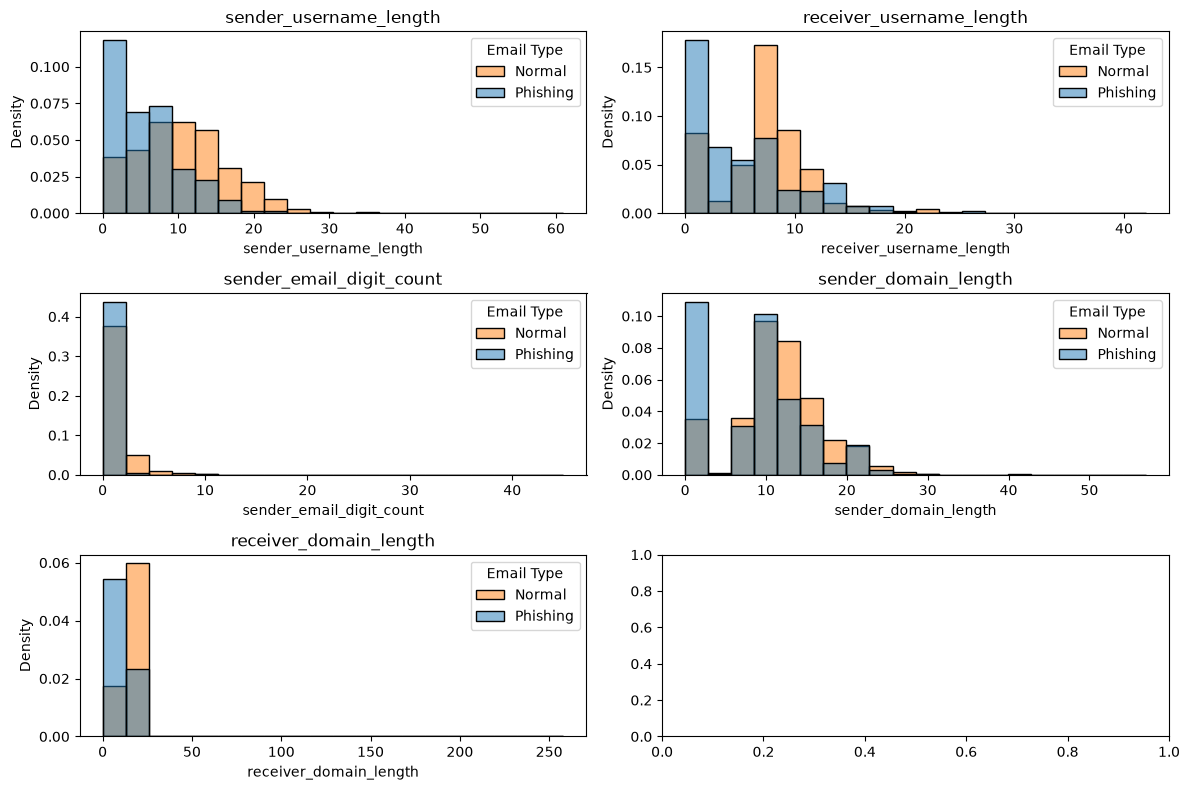

In [15]:
count_features = [
    "sender_username_length",
    "receiver_username_length",
    "sender_email_digit_count",
    "sender_domain_length",
    "receiver_domain_length",
]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), count_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="label",
        bins=20,
        stat="density",
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.legend(title="Email Type", labels=["Normal", "Phishing"])
    ax.set_title(feature)

plt.tight_layout()

df.groupby("label")[count_features].agg(
    ['median', 'mean', 'std']
)

From the results, we find that:
- Normal sender email addresses within `sender_username_length` tend towards **shorter usernames**, while phishing emails tend to come from senders with longer username.
This is shown in the normal email median length being 5, as compared with 11 for the median phishing email length.
- Sender email addresses with **lower or no digits** (`sender_email_digit_count`) tend to be normal emails as compared with phishing emails. This is shown through the mean count of digits in normal
emails is 0.16, as 0.87 for phishing emails.
- Sender email addresses with **longer domain lengths** (`sender_domain_length`) are more likely to be phishing emails then normal emails
- Receiver usernames (`receiver_username_length`) and domain lengths (`receiver_domain_length`) **don't have clear seperation** between normal and phishing emails,
which is expected since attackers don't have control over the recipient's email address and domain

Therefore, we keep the drop the receiver email address features (`receiver_username_length`, `receiver_domain_length`) due to their **low predictive value** and keep the rest.

In [16]:
df = df.drop(['receiver_username_length', 'receiver_domain_length'], axis=1)
df

,subject,label,body,urls,is_date_invalid,hour,day_of_week,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,0,0,0,0,5,9
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,0,0,4,0,12,9
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,0,0,0,1,19,19
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,0,0,0,0,7,9
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,0,0,1,0,12,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,1,0,4,0,14,14
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,0,0,3,0,13,10
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,0,0,2,0,18,10
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,0,0,2,0,14,11


## Data Cleaning & Preprocessing

After completing EDA, we now prepare the dataset for the model.

The `hour` and `day_of_week` are **periodic features** (i.e. they happen in cycles and repeat),
hence encoding this features with a raw number may result in models seeing a big jump between values that are actually adjacent,
such as between **11:00 PM (23)** and **12:00AM (0)** for `hour`.

Therefore, in order to ensure that the model capture the cyclic nature of these features, we use **cyclic encoding** (sin / cos) to encode these fields.

**Both the sine and cosine** is used to create unique values for each value of `hour` and `day_of_week`,
since just using one function results in duplicates sharing the same value.

The original `hour` and `day_of_week` fields are dropped.

,subject,label,body,urls,is_date_invalid,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,0,0,0,0,5,9,-0.258819,0.965926,0.781831,0.623490
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,0,0,4,0,12,9,-0.258819,0.965926,0.781831,0.623490
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,0,0,0,1,19,19,0.866025,-0.500000,0.974928,-0.222521
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,0,0,0,0,7,9,-0.258819,0.965926,0.781831,0.623490
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,0,0,1,0,12,19,-0.258819,0.965926,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,1,0,4,0,14,14,0.000000,0.000000,0.000000,0.000000
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,0,0,3,0,13,10,-0.500000,0.866025,0.000000,1.000000
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,0,0,2,0,18,10,0.500000,-0.866025,0.781831,0.623490
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,0,0,2,0,14,11,-0.258819,0.965926,0.781831,0.623490


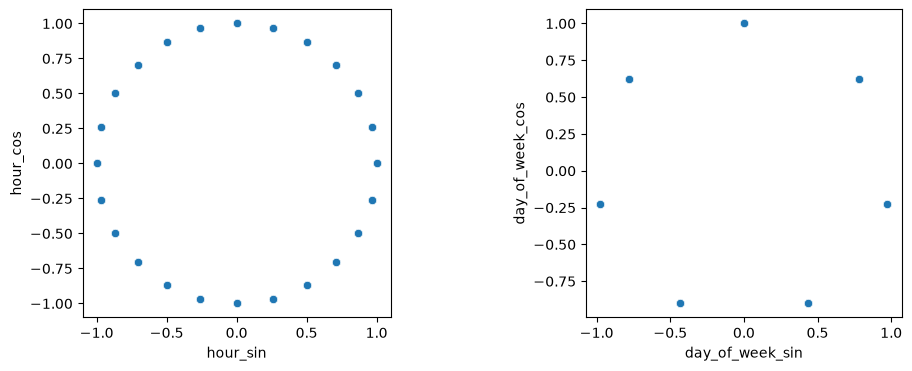

In [17]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

df = df.drop(['hour', 'day_of_week'], axis=1)

# we encode the features with both sin and cos to allow the model to capture the relationship below
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(df, x='hour_sin', y='hour_cos', ax=ax[0]).set_aspect('equal')
sns.scatterplot(df, x='day_of_week_sin', y='day_of_week_cos', ax=ax[1]).set_aspect('equal')
plt.plot()

# handle any null values
df[['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']] = df[['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']].fillna(0)

df

To keep consistent with the labels, we rename `urls` to `does_body_contain_urls`

In [18]:
df["does_body_contains_urls"] = df["urls"]
df = df.drop('urls', axis=1)
df

,subject,label,body,is_date_invalid,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,does_body_contains_urls
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",0.0,0,0,0,0,5,9,-0.258819,0.965926,0.781831,0.623490,1
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,0.0,0,0,4,0,12,9,-0.258819,0.965926,0.781831,0.623490,1
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,0.0,0,0,0,1,19,19,0.866025,-0.500000,0.974928,-0.222521,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,0.0,0,0,0,0,7,9,-0.258819,0.965926,0.781831,0.623490,1
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,0.0,0,0,1,0,12,19,-0.258819,0.965926,0.781831,0.623490,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",1.0,1,0,4,0,14,14,0.000000,0.000000,0.000000,0.000000,0
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,0.0,0,0,3,0,13,10,-0.500000,0.866025,0.000000,1.000000,1
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,0.0,0,0,2,0,18,10,0.500000,-0.866025,0.781831,0.623490,1
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",0.0,0,0,2,0,14,11,-0.258819,0.965926,0.781831,0.623490,1


For pre-processing the `body` and `subject`, we use a BERT preprocessor and backbone (from KerasHub) to bring the two features together before passing it to the model.

Hence, since `body` and `subject` works with tokens and not numerical values, we seperate it from our numerical features after spliting.

In [19]:
X = df.drop(['label'], axis=1)
y = df['label']

X_train, X_remain, y_train, y_remain = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_validate, X_test, y_validate, y_test = train_test_split(X_remain, y_remain, test_size=0.5, random_state=42, stratify=y_remain)

X_train_text = X_train[["subject", "body"]]
X_test_text = X_test[["subject", "body"]]
X_validate_text = X_validate[["subject", "body"]]

X_train = X_train.drop(['subject', 'body'], axis=1)
X_test = X_test.drop(['subject', 'body'], axis=1)
X_validate = X_validate.drop(['subject', 'body'], axis=1)

Since the dataset features have different value ranges, we scale them using `StandardScaler`.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_validate_scaled = scaler.transform(X_validate)

X_train_scaled.shape

(47548, 12)

Now, we perform processing on `body` and `subject` to obtain embeddings from the tokens to be combined with the main dataset.

We first concatenate the `subject` and `body` together as a single string before passing it into BERT.

This is done so that the model is able to capture the relationship between the `subject` and `body` fields within the email.

In [21]:
X_train_text = (
    X_train_text["subject"] +
    " [SEP] " +
    X_train_text["body"]
)

X_validate_text = (
    X_validate_text["subject"] +
    " [SEP] " +
    X_validate_text["body"]
)

X_test_text = (
    X_test_text["subject"] +
    " [SEP] " +
    X_test_text["body"]
)

We define the BERT preprocessor that will parse the text into tokens that can be used for creating the embeddings, and pass each `X` into it.

Within each email, we use the default `sequence_length` of 512 tokens.

In [22]:
# gpu optimization
keras.mixed_precision.set_global_policy("mixed_float16")

preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=512,
)

I0000 00:00:1785473961.891201    2506 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4159 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [23]:
train_tokens = preprocessor(tf.constant(X_train_text.tolist(), dtype=tf.string))
validate_tokens = preprocessor(tf.constant(X_validate_text.tolist(), dtype=tf.string))
test_tokens = preprocessor(tf.constant(X_test_text.tolist(), dtype=tf.string))

2026-07-31 12:59:28.773529: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


With the tokens obtained, we define the BERT backbone that will be used for generating the embeddings.

In [24]:
backbone = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased",
)

backbone.trainable = False

In [25]:
token_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="token_ids"
)

segment_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="segment_ids"
)

mask_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="padding_mask"
)

outputs = backbone({
    "token_ids": token_input,
    "segment_ids": segment_input,
    "padding_mask": mask_input
})

embedding = keras.Model(
    inputs=[
        token_input,
        segment_input,
        mask_input
    ],
    outputs=outputs["pooled_output"]
)

In [26]:
#train_token_dataset = (
#    tf.data.Dataset
#    .from_tensor_slices(train_tokens)
#    .batch(64)
#    .prefetch(tf.data.AUTOTUNE)
#)
#
#test_token_dataset = (
#    tf.data.Dataset
#    .from_tensor_slices(test_tokens)
#    .batch(64)
#    .prefetch(tf.data.AUTOTUNE)
#)
#
#validate_token_dataset = (
#    tf.data.Dataset
#    .from_tensor_slices(validate_tokens)
#    .batch(64)
#    .prefetch(tf.data.AUTOTUNE)
#)

#X_train_embeddings = embedding.predict(train_token_dataset)
#X_test_embeddings = embedding.predict(test_token_dataset)
#X_validate_embeddings = embedding.predict(validate_token_dataset)

#np.save("./embeddings/X_train_embeddings.npy", X_train_embeddings)
#np.save("./embeddings/X_test_embeddings.npy", X_test_embeddings)
#np.save("./embeddings/X_validate_embeddings.npy", X_validate_embeddings)

X_train_embeddings = np.load("./embeddings/X_train_embeddings.npy")
X_test_embeddings = np.load("./embeddings/X_test_embeddings.npy")
X_validate_embeddings = np.load("./embeddings/X_validate_embeddings.npy")

print(X_train_embeddings.shape)
print(X_test_embeddings.shape)
print(X_validate_embeddings.shape)

2026-07-31 12:59:33.162820: I external/local_xla/xla/service/service.cc:163] XLA service 0x272da810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-31 12:59:33.162836: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-07-31 12:59:33.233955: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-31 12:59:33.660100: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400
2026-07-31 12:59:34.768289: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 8 bytes spill stores, 8 bytes spill loads

2026-07-31 12:59:35.333023: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptx

742/743 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step  

2026-07-31 13:06:30.186729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_550', 8 bytes spill stores, 8 bytes spill loads

2026-07-31 13:06:30.530415: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 8 bytes spill stores, 8 bytes spill loads

2026-07-31 13:06:31.040009: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_550', 976 bytes spill stores, 948 bytes spill loads



743/743 ━━━━━━━━━━━━━━━━━━━━ 422s 560ms/step
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step 

2026-07-31 13:07:25.474861: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 8 bytes spill stores, 8 bytes spill loads

2026-07-31 13:07:25.556938: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_550', 8 bytes spill stores, 8 bytes spill loads

2026-07-31 13:07:26.115573: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_550', 976 bytes spill stores, 948 bytes spill loads



93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 591ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 50s 540ms/step
(47548, 768)
(5944, 768)
(5944, 768)


In [27]:
X_train_classifier = np.concatenate(
    [
        X_train_embeddings,
        X_train_scaled
    ],
    axis=1
)

## Model Building

In [28]:
classifier = keras.Sequential([
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(2, activation='softmax'), # generates 2 classes, with probability [indexes: 0 => normal, 1 => phishing]
])

In [29]:
classifier.compile(
    optimizer=keras.optimizers.Adam(2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Model Training

In [30]:
classifier.fit(
    X_train_classifier,
    y_train,
    validation_data=(
        np.concatenate(
            [X_validate_embeddings, X_validate_scaled],
            axis=1
        ),
        y_validate
    ),
    epochs=20,
    batch_size=32
)

Epoch 1/20


2026-07-31 13:08:21.038864: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-31 13:08:21.038911: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-31 13:08:21.038926: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-31 13:08:21.038934: I external/l

1483/1486 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7591 - loss: 0.5116

2026-07-31 13:08:25.676815: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-31 13:08:25.676869: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1486/1486 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7592 - loss: 0.5113

2026-07-31 13:08:28.051886: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-31 13:08:29.261122: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1486/1486 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7592 - loss: 0.5113 - val_accuracy: 0.8863 - val_loss: 0.3392
Epoch 2/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8829 - loss: 0.3160 - val_accuracy: 0.9224 - val_loss: 0.2276
Epoch 3/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9160 - loss: 0.2297 - val_accuracy: 0.9433 - val_loss: 0.1710
Epoch 4/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9329 - loss: 0.1853 - val_accuracy: 0.9477 - val_loss: 0.1444
Epoch 5/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9413 - loss: 0.1596 - val_accuracy: 0.9564 - val_loss: 0.1253
Epoch 6/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9485 - loss: 0.1422 - val_accuracy: 0.9573 - val_loss: 0.1142
Epoch 7/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9530 - loss: 0.1295 - val_accuracy: 0.9638 - val_loss: 0.1060
Epoch 8/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9555 - loss: 0.1206 - val_accura

In [31]:
X_test_classifier = np.concatenate(
    [
        X_test_embeddings,
        X_test_scaled
    ],
    axis=1
)

test_loss, test_accuracy = classifier.evaluate(
    X_test_classifier,
    y_test
)

print(test_accuracy)

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9761 - loss: 0.0685  
0.9761103391647339


In [32]:
y_pred_probs = classifier.predict(
    X_test_classifier
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "normal",
            "phishing"
        ]
    )
)

186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    
              precision    recall  f1-score   support

      normal       0.98      0.97      0.98      3106
    phishing       0.97      0.98      0.98      2838

    accuracy                           0.98      5944
   macro avg       0.98      0.98      0.98      5944
weighted avg       0.98      0.98      0.98      5944



[[3013   93]
 [  49 2789]]


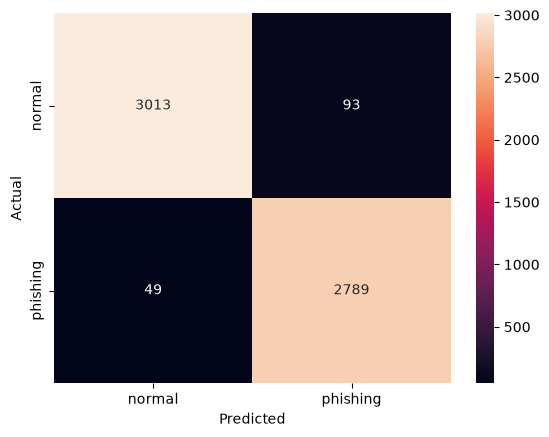

In [33]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["normal", "phishing"],
    yticklabels=["normal", "phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
probs = classifier.predict(
    X_test_classifier
)

errors_df = pd.DataFrame({
    "text": X_test_text,
    "actual": y_test,
    "predicted": y_pred,
    "phishing_probability": probs[:,1]
})

errors_df = errors_df[
    errors_df.actual != errors_df.predicted
]

errors_df.sort_values(
    "phishing_probability"
)

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step


/home/prism/dev/repos/phishing-detection-with-bert-tokenizer/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,text,actual,predicted,phishing_probability
58399,Investment Idea [SEP] This is a Brand New Comp...,1.0,0,0.000069
41928,No Subject [SEP] How come it takes so little t...,1.0,0,0.000174
42119,No Subject [SEP] Do you ever notice that when ...,1.0,0,0.001965
55774,Summer Job Interviews. . . . [SEP] ------ack12...,1.0,0,0.016663
54531,[ILUG-Social] Everybody Gets Paid - No Recruit...,1.0,0,0.022888
...,...,...,...,...
50462,[zzzzteana] FW: please give generously [SEP] -...,0.0,1,0.961426
30726,Policy Patrol quarantine report *LUXIO* [SEP]...,0.0,1,0.967773
54318,Re: Hi! I'm new here. [SEP] This is a multi-pa...,0.0,1,0.979980
21956,2008Examkevinfinal.xls [SEP] Just to make cert...,0.0,1,0.983887
